# Video Idea Leads

This notebook finds YouTube video idea leads: videos that performed abnormally well relative to the creator's weight class, not merely videos from already-huge channels. The core heuristic is to look for small or mid-sized channels punching above their subscriber and maturity class (for example, a 10k-subscriber channel getting 1M views), using subscribers, video count, per-video views, and comments as triangulation metrics.

Shorts defense has two layers. First, this notebook excludes videos of 60 seconds or less by default. The product concern is that a Short reaching 1M views is a weaker video-idea signal than a long-form video reaching 1M views, because Shorts often accumulate views through a low-intent feed mechanic rather than deliberate audience demand. The exclusion runs inside `load_analysis_frame` before enrichment, so channel-relative baselines and weight-class norms are computed from long-form videos only; matching snapshots are filtered to the surviving video set too.

Second, the final composite shortlist can run a Shorts verification probe. Duration alone is insufficient because YouTube raised the Shorts limit to 3 minutes in Oct 2024, so Shorts in the 61-180s band can slip past a 60-second cutoff. The probe sends `HEAD https://www.youtube.com/shorts/<video_id>` only for over-fetched top candidates: HTTP 200 confirms a Short, while a redirect means the video is not a Short. Confirmed Shorts are dropped before the final top-N truncation; network errors or timeouts are fail-open (`undetermined`) and are kept deliberately so a transient probe failure cannot silently remove a real lead.

Language filtering is the third defence, and it runs at the same point as the Shorts exclusion and for the same reason: a Spanish-language channel is not a lead for an English-speaking audience, and leaving it in the corpus also distorts the weight-class norms, theme lift, and niche saturation that everything downstream is measured against.

A channel's language is decided by a stack of evidence, strongest first, and `language_source` reports which tier made each call.

`audio` is YouTube's `defaultAudioLanguage`, which arrives free with the `part=snippet` call the collector already makes and describes what a viewer will *hear*. `text` is `defaultLanguage`, which only describes the language the title is written in; the two are ranked rather than pooled, because a Bollywood upload is Hindi audio under a romanized English title, so they disagree by construction and treating that as a tie hands the decision to a detector that reads romanized Hindi as English. `region` catches English from a non-western market: YouTube reports it in the tag itself (`en-IN`), which is lost by reducing a tag to its primary subtag. `script` catches titles written in Devanagari, Arabic, CJK and the like, which is objective evidence that a typed `en` cannot outrank. `markers` is the last tier and the only one that reaches romanized content. `detected` means no metadata existed and fastText lid.176 guessed from the channel's pooled titles.

A channel counts as English only when nothing contradicts it: any non-English tag disqualifies it rather than being outvoted, since a channel posting mostly in English with occasional Hindi uploads is not a clean source of English-audience ideas. This deliberately trades recall for precision.

The `markers` tier exists because the layers above it all fail on the same population. A title like "Banjaara (Full Audio) | Ek Villain | Sidharth Malhotra" is pure ASCII, so no script check sees anything; every language-ID model tested (langdetect, lingua, py3langid, fastText lid.176, GlotLID) calls it English; and the uploader set `defaultAudioLanguage=en`, so YouTube agrees. Only the vocabulary gives it away. That vocabulary is *learned* rather than hand-written: `scripts/train_language_markers.py` mines tokens from the channels YouTube labelled with a South Asian audio language and keeps those that essentially never appear on English-labelled channels, so the metadata that is reliable on most channels teaches the filter to catch the ones where it is missing or wrong. On held-out channels it recalls about three quarters of them at roughly a 1% false-positive rate, and inspection showed most of those "false positives" were Indian-market channels YouTube had simply mislabelled. Re-run that script after a large ingest to refresh the list.

Set `ENGLISH_ONLY = False` to keep every language, and `KEEP_UNKNOWN_LANGUAGE = False` to also drop channels that no source could label. Channels ruled out by the `region`, `script` or `markers` tiers are never kept as "unlabelled", because having no evidence and having evidence against are different states. Run `make backfill-languages` to fetch metadata for videos collected before the language columns existed, and `make lid-model` once to install the fallback model.

The two slow steps (loading/enriching the joined frame and running the six scoring algorithms) are checkpointed to Parquet under `data/cache/leads/`, so a kernel restart reloads results instead of recomputing them for several minutes. Entries are keyed by the database contents (row counts and max ids of the tables the analysis reads), by the analysis parameters, and by a hash of the `scripts/RecomendationAnalysis` sources; ingesting new rows, tuning a parameter, or editing an algorithm therefore produces a fresh entry rather than a stale hit. Content keying is used instead of file mtime because collectors write to `skimmer.db` continuously, so an mtime key would miss on nearly every run; set `CACHE_DB_FINGERPRINT = 'path'` to pin the cache to whatever was computed last regardless of new ingests. Set `USE_CACHE = False` to bypass the cache entirely or `REFRESH_CACHE = True` to recompute and overwrite. Cache read/write failures are non-fatal and fall back to recomputation.

- Default DB path: `data/skimmer.db`
- Override with env var: `SKIMMER_DB_PATH`
- Outputs a composite lead table plus a CSV export in `data/output/`

Algorithm columns:

- `breakout_outliers`: small-channel videos with extreme views-per-subscriber.
- `weight_class_performance`: top percentile videos within subscriber and video-count peer groups.
- `channel_relative`: videos far above their own channel's typical view baseline.
- `velocity`: videos with unusually strong publish velocity or recent re-acceleration.
- `engagement`: videos with unusually high comment/like resonance for their class.
- `topics`: recurring title themes among already-identified outlier leads.

## 1. Setup

In [1]:
import copy
import html
import os
import sys
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import HTML, display


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'scripts' / 'RecomendationAnalysis').is_dir() and (candidate / 'data').is_dir():
            return candidate
    raise RuntimeError('Could not locate the skimmer repository root from the current directory.')


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from scripts.RecomendationAnalysis import checkpoint, data_access, exclusions, language_frames, leads as ra_leads, metrics
from scripts.RecomendationAnalysis.algorithms import topics

DEFAULT_DB_PATH = Path('data/skimmer.db')
_env_db_path = os.environ.get('SKIMMER_DB_PATH')
DB_PATH = Path(_env_db_path).expanduser() if _env_db_path else REPO_ROOT / DEFAULT_DB_PATH
if not DB_PATH.is_absolute():
    DB_PATH = REPO_ROOT / DB_PATH
DB_PATH = data_access.resolve_db_path(DB_PATH)

print(f'Using database: {DB_PATH.resolve()}')

Using database: /home/orangepi/code_projects/skimmer/data/skimmer.db


## 2. Parameters

Edit this single cell to tune the notebook. All downstream cells read from these values.

In [2]:
# PARAMETERS
TOP_N = 100
EXCLUDE_SHORTS = True  # Exclude videos at or below the Shorts duration cutoff from all downstream analysis.
SHORTS_MAX_DURATION_SECONDS = 60  # Duration cutoff for the bulk Shorts filter before enrichment/baselines.
DROP_UNKNOWN_DURATION = False  # Keep videos with missing duration instead of treating them as Shorts.

# Language filter. Non-English channels are dropped before enrichment, exactly like Shorts, so
# weight-class norms, theme lift and niche saturation describe the English-speaking market.
# The language of a channel comes from YouTube's own defaultAudioLanguage/defaultLanguage first
# (free with the collector's existing snippet call, and the only source that gets romanized
# Hindi/Punjabi titles right); channels YouTube never tagged fall back to the fastText lid.176
# model, which needs a one-off `make lid-model`.
ENGLISH_ONLY = True  # False keeps every language in the corpus.
KEEP_UNKNOWN_LANGUAGE = True  # Keep channels no source could label; False is stricter but loses leads.

# Network note: Shorts verification is the only notebook behavior that makes network requests.
# Set VERIFY_SHORTS = False to make the notebook fully offline.
VERIFY_SHORTS = True  # Probe the final over-fetched shortlist via YouTube Shorts URLs.
VERIFY_SHORTS_MAX_WORKERS = 8  # Concurrent HEAD requests for the final-shortlist probe.
VERIFY_SHORTS_TIMEOUT = 8.0  # Per-request timeout in seconds; timeouts are kept fail-open.
VERIFY_SHORTS_OVER_FETCH = 2.0  # Probe TOP_N * this many candidates before dropping confirmed Shorts.
VERIFY_SHORTS_CACHE = None  # None uses data/output/shorts_probe_cache.json for cheap re-runs.

# Checkpoint cache: the slow load/enrich and algorithm-scoring steps are persisted as Parquet
# so a kernel restart reloads them instead of recomputing for several minutes.
USE_CACHE = True  # False bypasses the cache entirely (no reads, no writes).
REFRESH_CACHE = False #True  # True recomputes the slow steps and overwrites the cached entries.
CACHE_DIR = None  # None uses data/cache/leads/.
# 'content' keys on row counts of the tables the analysis reads, so unrelated collector writes do not
# invalidate the cache. 'mtime' keys on file size/mtime; 'path' ignores data changes entirely.
CACHE_DB_FINGERPRINT = 'content'

WEIGHTS = copy.deepcopy(ra_leads.DEFAULT_WEIGHTS)

PARAMS = {
    name: copy.deepcopy(getattr(module, 'DEFAULT_PARAMS', {}))
    for name, module in ra_leads.ALGORITHMS.items()
}
# Keep topic extraction on the stdlib path by default; the sklearn path can be memory-heavy on the full corpus.
PARAMS['topics']['use_sklearn'] = False

# Persistent title-term exclusions, edited in section 11 and saved to data/title_exclusions.json.
# Reloaded here so a rule added in a previous session applies from the top of this run.
EXCLUSIONS_PATH = None  # None uses data/title_exclusions.json.
EXCLUSION_RULES = exclusions.load(EXCLUSIONS_PATH)
CORPUS_EXCLUSIONS = exclusions.canonical(exclusions.for_scope(EXCLUSION_RULES, 'corpus'))
LEAD_EXCLUSIONS = exclusions.canonical(exclusions.for_scope(EXCLUSION_RULES, 'leads'))

FILTERS = {
    'max_per_channel': 3,
    # Optional examples:
    # 'max_subscribers': 200_000,
    # 'min_views': 25_000,
    # 'sub_class': ['1k-10k', '10k-50k', '50k-200k'],
}

EXPORT = True
EXPORT_PATH = REPO_ROOT / 'data' / 'output' / f"{datetime.now().strftime('%Y-%m-%d%H%M%S')}.csv"

display(pd.DataFrame({'algorithm': list(WEIGHTS), 'weight': list(WEIGHTS.values())}))
print(f'Shorts filter: exclude_shorts={EXCLUDE_SHORTS}, cutoff_seconds={SHORTS_MAX_DURATION_SECONDS}, drop_unknown_duration={DROP_UNKNOWN_DURATION}')
print(f'Language filter: english_only={ENGLISH_ONLY}, keep_unknown_language={KEEP_UNKNOWN_LANGUAGE}')
print(f'Shorts probe: verify_shorts={VERIFY_SHORTS}, max_workers={VERIFY_SHORTS_MAX_WORKERS}, timeout={VERIFY_SHORTS_TIMEOUT}, over_fetch={VERIFY_SHORTS_OVER_FETCH}, cache={VERIFY_SHORTS_CACHE}')
print('Network note: VERIFY_SHORTS controls the only network traffic in this notebook; set VERIFY_SHORTS=False for a fully offline run.')
print(f'Checkpoint cache: use_cache={USE_CACHE}, refresh={REFRESH_CACHE}, db_fingerprint={CACHE_DB_FINGERPRINT}, dir={checkpoint.resolve_cache_dir(CACHE_DIR)}')
print(f'Export path: {EXPORT_PATH}')
print(
    f'Exclusions: {len(EXCLUSION_RULES)} rule(s) from {exclusions.default_path() if EXCLUSIONS_PATH is None else EXCLUSIONS_PATH} '
    f'({len(CORPUS_EXCLUSIONS)} corpus-scoped, {len(LEAD_EXCLUSIONS)} lead-scoped).'
)


,algorithm,weight
0,breakout_outliers,1.35
1,weight_class_performance,1.35
2,channel_relative,1.05
3,velocity,0.85
4,engagement,0.60
5,topics,0.35


Shorts filter: exclude_shorts=True, cutoff_seconds=60, drop_unknown_duration=False
Language filter: english_only=True, keep_unknown_language=True
Shorts probe: verify_shorts=True, max_workers=8, timeout=8.0, over_fetch=2.0, cache=None
Network note: VERIFY_SHORTS controls the only network traffic in this notebook; set VERIFY_SHORTS=False for a fully offline run.
Checkpoint cache: use_cache=True, refresh=False, db_fingerprint=content, dir=/home/orangepi/code_projects/skimmer/data/cache/leads
Export path: /home/orangepi/code_projects/skimmer/data/output/2026-08-06101039.csv
Exclusions: 6 rule(s) from /home/orangepi/code_projects/skimmer/data/title_exclusions.json (0 corpus-scoped, 6 lead-scoped).


## 3. Data Load + Corpus Summary

In [3]:
# Slow step: loads and enriches the latest video/channel frame and optional video snapshots once.
# The configured shorts and language filters are applied inside load_analysis_frame before
# metrics.enrich, so every downstream table and plot reuses this long-form, English-only frame.
# Both the raw joined frame and the enriched frame are checkpointed to Parquet, so a kernel
# restart reloads them unless the database changed, the parameters changed, or REFRESH_CACHE is set.
FRAME_KWARGS = {
    'with_snapshots': True,
    'exclude_shorts': EXCLUDE_SHORTS,
    'shorts_max_duration_seconds': SHORTS_MAX_DURATION_SECONDS,
    'drop_unknown_duration': DROP_UNKNOWN_DURATION,
    'english_only': ENGLISH_ONLY,
    'keep_unknown_language': KEEP_UNKNOWN_LANGUAGE,
    # Only corpus-scoped rules belong here. They change the frame (and therefore the norms),
    # so they must be part of its cache key; lead-scoped rules are applied to cached scores
    # further down and would otherwise discard this checkpoint for no reason.
    'exclusion_rules': CORPUS_EXCLUSIONS,
}

raw_frames, raw_from_cache = checkpoint.cached_frames(
    checkpoint.make_key('raw_joined', DB_PATH, db_fingerprint_mode=CACHE_DB_FINGERPRINT),
    lambda: {'raw_df': data_access.load_joined(db_path=DB_PATH)},
    cache_dir=CACHE_DIR,
    use_cache=USE_CACHE,
    refresh=REFRESH_CACHE,
)
raw_df = raw_frames['raw_df']
raw_duration_flags = metrics.add_duration_flags(raw_df, max_duration_seconds=SHORTS_MAX_DURATION_SECONDS)
raw_is_short = raw_duration_flags['is_short']
raw_unknown_duration = pd.to_numeric(raw_df['duration_seconds'], errors='coerce').isna()

full_df, snapshots, frame_from_cache = checkpoint.load_analysis_frame_cached(
    DB_PATH,
    cache_dir=CACHE_DIR,
    use_cache=USE_CACHE,
    refresh=REFRESH_CACHE,
    db_fingerprint_mode=CACHE_DB_FINGERPRINT,
    **FRAME_KWARGS,
)
print(f"Raw joined frame: {'loaded from cache' if raw_from_cache else 'computed'}.")
print(f"Analysis frame: {'loaded from cache' if frame_from_cache else 'computed'}.")

filtered_duration = pd.to_numeric(full_df['duration_seconds'], errors='coerce')
filter_summary = pd.DataFrame(
    [
        {'metric': 'videos_before_shorts_filter', 'value': len(raw_df)},
        {'metric': 'videos_after_shorts_filter', 'value': len(full_df)},
        {'metric': 'shorts_removed', 'value': int(raw_is_short.fillna(False).sum()) if EXCLUDE_SHORTS else 0},
        {'metric': 'unknown_duration_videos_before', 'value': int(raw_unknown_duration.sum())},
        {'metric': 'unknown_duration_videos_retained', 'value': int(filtered_duration.isna().sum())},
        {'metric': 'shorts_cutoff_seconds', 'value': SHORTS_MAX_DURATION_SECONDS},
    ]
)
display(filter_summary)
print('Shorts are excluded from the shared analysis frame used by every downstream section.' if EXCLUDE_SHORTS else 'Shorts exclusion is disabled; downstream sections include all durations.')

# Corpus-scoped exclusions were applied inside load_analysis_frame, before metrics.enrich, so
# their matches never reached the weight-class norms, theme lift or niche saturation. The hit
# counts are measured against raw_df because full_df no longer contains the removed rows.
if CORPUS_EXCLUSIONS:
    corpus_exclusion_hits = exclusions.summarize(raw_df, CORPUS_EXCLUSIONS)
    print(f'Corpus-scoped exclusions: {len(CORPUS_EXCLUSIONS)} rule(s) matching {int(corpus_exclusion_hits["matched_rows"].sum()):,} raw videos.')
    display(corpus_exclusion_hits)
else:
    print('No corpus-scoped exclusions; every surviving video contributes to the norms.')

# What the language filter removed, and how much of it rested on inference rather than
# on YouTube's own metadata.
if ENGLISH_ONLY:
    raw_languages = language_frames.annotate(raw_df)
    display(language_frames.summarize(raw_languages).head(12))

    # How much of the surviving corpus rests on decisive evidence. 'audio' is
    # YouTube's defaultAudioLanguage and settles it; 'text' means only the
    # title's own language was set, which is 'en' for any transliterated title;
    # 'detected' means nothing was set and the model guessed from titles, where
    # romanized Hindi and Punjabi read as English. Rows marked text/detected in
    # the tables below are unverified rather than confirmed English. The
    # region/script/markers tiers only ever exclude, so they never appear here.
    kept_channels = full_df.drop_duplicates('channel_id')
    evidence = kept_channels['language_source'].value_counts().rename('channels').to_frame()
    evidence['share'] = (evidence['channels'] / len(kept_channels)).round(3)
    display(evidence)
    print(
        f"Language filter: {len(raw_df) - len(full_df):,} videos removed in total "
        f"(shorts and non-English combined); {full_df['channel_id'].nunique():,} channels remain."
    )
    weak = int(evidence['channels'].reindex(['text', 'detected']).fillna(0).sum())
    if weak:
        print(
            f'{weak:,} surviving channels are English on weak evidence (no defaultAudioLanguage). '
            'Run `make backfill-languages` again to convert some of them to audio evidence.'
        )
else:
    print('Language filtering is disabled; downstream sections include every language.')

known_duration = pd.to_numeric(raw_df['duration_seconds'], errors='coerce').dropna()
duration_summary = pd.DataFrame(
    [
        {'bucket': '<= 60s (shorts)', 'videos': int((known_duration <= SHORTS_MAX_DURATION_SECONDS).sum())},
        {'bucket': '61s-5m', 'videos': int(((known_duration > SHORTS_MAX_DURATION_SECONDS) & (known_duration <= 300)).sum())},
        {'bucket': '5m-20m', 'videos': int(((known_duration > 300) & (known_duration <= 1200)).sum())},
        {'bucket': '> 20m', 'videos': int((known_duration > 1200).sum())},
        {'bucket': 'unknown duration', 'videos': int(raw_unknown_duration.sum())},
    ]
)
display(duration_summary)

summary = pd.DataFrame(
    [
        {'metric': 'videos', 'value': len(full_df)},
        {'metric': 'snapshot_rows', 'value': 0 if snapshots is None else len(snapshots)},
        {
            'metric': 'videos_with_2plus_snapshots',
            'value': 0
            if snapshots is None or snapshots.empty
            else int(snapshots.groupby('video_id', observed=True).size().ge(2).sum()),
        },
        {'metric': 'channels', 'value': full_df['channel_id'].nunique() if 'channel_id' in full_df else np.nan},
    ]
)
display(summary)

published = pd.to_datetime(full_df.get('published_at'), errors='coerce', utc=True)
display(pd.DataFrame({'published_at_min': [published.min()], 'published_at_max': [published.max()]}))

class_crosstab = pd.crosstab(full_df['sub_class'], full_df['video_count_class'], dropna=False)
display(class_crosstab)

key_metrics = [
    'subscribers',
    'video_count',
    'views',
    'comments',
    'views_per_sub',
    'channel_relative_multiple',
    'comment_rate',
    'views_per_day',
    'video_age_days',
]
null_rates = (
    full_df[key_metrics]
    .isna()
    .mean()
    .rename('null_rate')
    .mul(100)
    .round(2)
    .reset_index()
    .rename(columns={'index': 'metric'})
)
display(null_rates)


No usable vidiq channel rows found for 80 missing channels.
No usable vidiq channel rows found for 80 missing channels.


Raw joined frame: computed.
Analysis frame: computed.


,metric,value
0,videos_before_shorts_filter,540873
1,videos_after_shorts_filter,286865
2,shorts_removed,108066
3,unknown_duration_videos_before,5728
4,unknown_duration_videos_retained,3305
5,shorts_cutoff_seconds,60


Shorts are excluded from the shared analysis frame used by every downstream section.
No corpus-scoped exclusions; every surviving video contributes to the norms.


,videos,channels,share
channel_language,,,
en,360156,17744,0.665879
es,44448,1864,0.082178
hi,34580,1216,0.063934
id,8160,420,0.015087
pt,7831,373,0.014478
zh,7796,245,0.014414
ru,7137,310,0.013195
ko,5655,203,0.010455
und,5300,370,0.009799


...

,bucket,videos
0,<= 60s (shorts),108066
1,61s-5m,104585
2,5m-20m,120115
3,> 20m,202379
4,unknown duration,5728


,metric,value
0,videos,286865
1,snapshot_rows,459254
2,videos_with_2plus_snapshots,82896
3,channels,17418


,published_at_min,published_at_max
0,2026-06-23 03:10:24+00:00,2026-08-06 01:21:19+00:00


video_count_class,<50,50-300,300-1000,1000+,unknown
sub_class,,,,,
<1k,18503,8757,2380,861,0
1k-10k,13826,23714,7771,7804,0
10k-50k,3634,17123,11699,15440,0
50k-200k,1043,8002,11482,24044,0
200k-1M,273,4584,12023,39984,0
1M+,68,1362,6211,45946,0
unknown,0,0,0,0,331


,metric,null_rate
0,subscribers,0.12
1,video_count,0.12
2,views,0.00
3,comments,1.36
4,views_per_sub,0.15
5,channel_relative_multiple,4.34
6,comment_rate,2.21
7,views_per_day,0.00
8,video_age_days,0.00


## 4. Shared Display Helpers

In [4]:
def _compact_number(value):
    if pd.isna(value):
        return ''
    try:
        number = float(value)
    except (TypeError, ValueError):
        return value
    absolute = abs(number)
    if absolute >= 1_000_000_000:
        return f'{number / 1_000_000_000:.2f}B'
    if absolute >= 1_000_000:
        return f'{number / 1_000_000:.2f}M'
    if absolute >= 1_000:
        return f'{number / 1_000:.1f}k'
    return f'{number:,.0f}'


def _format_value(value):
    if pd.isna(value):
        return ''
    if isinstance(value, (int, np.integer)):
        return f'{value:,}'
    if isinstance(value, (float, np.floating)):
        if abs(value) >= 1000:
            return _compact_number(value)
        return f'{value:.3f}'.rstrip('0').rstrip('.')
    return str(value)


def _anchor(url, text):
    text = '' if pd.isna(text) else str(text)
    if pd.isna(url) or not str(url).strip():
        return html.escape(text)
    return f'<a href="{html.escape(str(url), quote=True)}" target="_blank">{html.escape(text)}</a>'


def display_link_table(frame, columns, limit=25, link_title=True):
    available = [column for column in columns if column in frame.columns]
    table = frame.head(limit).loc[:, available].copy()
    if link_title and 'title' in table.columns and 'video_url' in frame.columns:
        urls = frame.head(limit)['video_url']
        table['title'] = [_anchor(url, title) for url, title in zip(urls, table['title'], strict=False)]
    if 'channel_name' in table.columns and 'channel_url' in frame.columns:
        urls = frame.head(limit)['channel_url']
        table['channel_name'] = [_anchor(url, name) for url, name in zip(urls, table['channel_name'], strict=False)]
    for column in table.columns:
        if column not in {'title', 'channel_name', 'reason', 'algorithms', 'reasons', 'matched_terms', 'category_name'}:
            table[column] = table[column].map(_format_value)
    display(HTML(table.to_html(escape=False, index=False)))


def with_language(frame):
    """Attach the channel language columns to an algorithm result frame.

    Algorithm outputs carry only video identity, but language is the thing most
    worth eyeballing on these tables: `language_source` says how the call was
    made. `audio` means YouTube reported the spoken language and is decisive;
    `text` means only the title's own language was set, which is `en` on any
    transliterated title and is therefore weak; `detected` means no metadata
    existed at all and the model guessed from titles, which reads romanized
    Hindi and Punjabi as English. Treat `text` and `detected` rows as unverified.
    """

    if frame.empty or 'video_id' not in frame.columns:
        return frame
    columns = [c for c in ('video_id', 'channel_language', 'language_source') if c in full_df.columns]
    if len(columns) < 2:
        return frame
    return frame.merge(full_df[columns].drop_duplicates('video_id'), on='video_id', how='left')


def warn_failures(frame):
    failures = frame.attrs.get('algorithm_failures', {})
    if failures:
        display(HTML('<h3 style="color: #b00020;">WARNING: algorithm failures detected</h3>'))
        display(pd.Series(failures, name='error').to_frame())

## 5. Run Algorithms Once

The next cell is expected to take several minutes on the full corpus. It is shared by every per-algorithm table and by the composite section.

In [5]:
# Slow step: run each scoring algorithm once and reuse these results below.
# Results are checkpointed per algorithm; the key covers PARAMS and the frame parameters above.
algorithm_results, algorithms_from_cache = checkpoint.run_algorithms_cached(
    full_df,
    snapshots=snapshots,
    db_path=DB_PATH,
    cache_dir=CACHE_DIR,
    params=PARAMS,
    frame_kwargs=FRAME_KWARGS,
    use_cache=USE_CACHE,
    refresh=REFRESH_CACHE,
    db_fingerprint_mode=CACHE_DB_FINGERPRINT,
)
print(f"Algorithm results: {'loaded from cache' if algorithms_from_cache else 'computed'}.")

# Lead-scoped exclusions act on the cached scores rather than before scoring, so a rule added
# after review costs a re-run of this cell instead of a full recompute. They are applied here,
# above normalize_scores, so the percentile ranks feeding the composite are computed over the
# population actually being ranked rather than over one that still contains the excluded rows.
if LEAD_EXCLUSIONS:
    _counts_before = {name: len(frame) for name, frame in algorithm_results.items()}
    algorithm_results = exclusions.apply_to_results(algorithm_results, LEAD_EXCLUSIONS)
    exclusion_removals = pd.Series(
        {name: _counts_before[name] - len(frame) for name, frame in algorithm_results.items()},
        name='rows_removed',
    ).rename_axis('algorithm')
    print(f'Lead-scoped exclusions: {len(LEAD_EXCLUSIONS)} rule(s) removed {int(exclusion_removals.sum()):,} scored rows.')
    display(exclusion_removals.to_frame())

algorithm_counts = pd.Series({name: len(frame) for name, frame in algorithm_results.items()}, name='lead_count')
display(algorithm_counts.to_frame())
for frame in algorithm_results.values():
    warn_failures(frame)


Algorithm results: computed.
Lead-scoped exclusions: 6 rule(s) removed 1,088 scored rows.


,rows_removed
algorithm,
breakout_outliers,184
weight_class_performance,155
channel_relative,288
velocity,74
engagement,207
topics,180


,lead_count
breakout_outliers,3251
weight_class_performance,2658
channel_relative,8264
velocity,1379
engagement,8282
topics,3821


### 5.1. Breakout Outliers

Videos with extreme views-per-subscriber, especially from small channels where reach exceeded the built-in audience.

In [6]:
breakout_outliers_top = algorithm_results.get('breakout_outliers', pd.DataFrame()).sort_values('score', ascending=False)
display_link_table(with_language(breakout_outliers_top), ['title', 'channel_name', 'subscribers', 'video_count', 'views', 'views_per_sub', 'score', 'reason', 'language_source'], limit=100)

title,channel_name,subscribers,video_count,views,views_per_sub,score,reason,language_source
No Celebrity Has ZERO Filter Like Clint Eastwood - and It’s HILARIOUS!,The Fame Fuel,1.5k,5,2.39M,1.6k,28.358,1634.9x views/sub on a 1.5k-sub channel (2.4M views),audio
Wayne Rooney and Micah Richards angry with Tuchel,Futro,2.0k,27,2.87M,1.4k,27.958,1407.5x views/sub on a 2k-sub channel (2.9M views),text
YARA YARA FUNK (Slowed + Reverb),Reyna Pentecost - Topic,3.5k,8,3.72M,1.1k,27.107,1062.2x views/sub on a 3.5k-sub channel (3.7M views),audio
No One Was Ready for Jim Carrey's Impressions,PapaPrime,1.1k,3,1.37M,1.3k,26.942,1294.8x views/sub on a 1.1k-sub channel (1.4M views),audio
Nobody Made Michael Jackson Laugh Like Chris Tucker,Chris Wick,6.1k,6,3.25M,534.435,24.329,534.4x views/sub on a 6.1k-sub channel (3.2M views),audio
When Your BABY Finds His BEST Friend 🥹🤣 Funny ANIMALS Videos 2026,Animal Kingdomedy,1.9k,7,1.12M,607.257,23.928,607.3x views/sub on a 1.9k-sub channel (1.1M views),text
Kwebbelkop laugh (Slowed + Reverb),MaxdryOnline,1.3k,11,844.7k,644.796,23.903,644.8x views/sub on a 1.3k-sub channel (844.7k views),text
🇺🇸Try Not To Laugh Challenge#funny#doddlersoftiktok #funnyvideos#duet#gaming#fyp#Los Angeles,김희정,8.1k,36,3.70M,459.495,23.849,459.5x views/sub on a 8.1k-sub channel (3.7M views),audio
the angry birds movie but it's just the memes,gromonkle,1.1k,14,629.9k,599.89,23.381,599.9x views/sub on a 1.1k-sub channel (629.9k views),audio
When Ryan Gosling Bought all the Girl Scout cookies...,W-clip-Farmer,3.7k,189,1.76M,473.164,23.364,473.2x views/sub on a 3.7k-sub channel (1.8M views),audio


### 5.2. Weight-Class Performance

Videos ranking at the top of their subscriber and channel-maturity peer group, so the score compares like with like.

In [7]:
weight_class_performance_top = algorithm_results.get('weight_class_performance', pd.DataFrame()).sort_values('score', ascending=False)
display_link_table(with_language(weight_class_performance_top), ['title', 'channel_name', 'subscribers', 'video_count', 'views', 'composite_raw', 'score', 'reason', 'language_source'], limit=100
                  )

title,channel_name,subscribers,video_count,views,composite_raw,score,reason,language_source
"Liz Waddell at Her Airbnb — Annotated Security Footage from July 22, 2026",Liz,24,2,19.7k,0.987,1,"top 0.0% of <1k subs / <50 videos peer group (n=18,503)",text
China quietly saved the world last month,Max Fisher,384.0k,36,3.98M,0.972,1,top 0.0% of 200k-1M subs / <50 videos peer group (n=273),audio
NOLAN WELLS: ENHANCED DISTRESS CALL BOMBSHELL,Nancy Grace,998.0k,1.9k,1.27M,0.987,1,"top 0.0% of 200k-1M subs / 1000+ videos peer group (n=39,984)",audio
Nick Fuentes Interview (Ft. Hunter Biden),Channel 5 with Andrew Callaghan,3.64M,432,4.70M,0.978,1,"top 0.0% of 1M+ subs / 300-1000 videos peer group (n=6,211)",audio
The Angry Birds Movie but there’s zero birds/bird references,Sheepe,633,65,218.5k,0.981,1,"top 0.0% of <1k subs / 50-300 videos peer group (n=8,757)",audio
NVIDIA Keynote Live at SIGGRAPH 2026,NVIDIA,2.23M,2.7k,7.40M,0.999,1,"top 0.0% of 1M+ subs / 1000+ videos peer group (n=45,946)",audio
Why Nobody's Eating McDonald's Anymore,Michael Girdley,325.0k,506,1.20M,0.985,1,"top 0.0% of 200k-1M subs / 300-1000 videos peer group (n=12,023)",audio
BODY POSITIONS!#cheerleader #cheer #cheerleading #stretching #flyer #flexible www.kinsleypetty.com,Kinsley Petty,36.1k,1.2k,151.8k,0.996,1,"top 0.0% of 10k-50k subs / 1000+ videos peer group (n=15,440)",text
Bricks and Minifigs Tried to Get Me Arrested to Stop This Video,Reckless Ben,1.66M,174,7.16M,0.988,1,"top 0.0% of 1M+ subs / 50-300 videos peer group (n=1,362)",audio
Scammer CRIES After I HACK Her Live Webcam!,NanoBaiter,1.24M,24,5.41M,0.952,1,top 0.0% of 1M+ subs / <50 videos peer group (n=68),text


### 5.3. Channel Relative

Videos that beat their own channel baseline by a large multiple, indicating an idea that overperformed the creator's usual demand.

In [8]:
channel_relative_top = algorithm_results.get('channel_relative', pd.DataFrame()).sort_values('score', ascending=False)
display_link_table(with_language(channel_relative_top), ['title', 'channel_name', 'subscribers', 'video_count', 'views', 'channel_relative_multiple', 'score', 'reason', 'language_source'], limit=25)

title,channel_name,subscribers,video_count,views,channel_relative_multiple,score,reason,language_source
Property owner warns others to fight back after squatter takeover,ABC 10 News,425.0k,82.4k,1.31M,2.1k,9.296,"2kx its channel's median (median 624 -> 1M views, n=80 videos)",audio
The Thomas Crown Affair | Official Teaser Trailer,Amazon MGM Studios,1.81M,2.5k,15.98M,3.0k,8.22,"3kx its channel's median (median 5k -> 16M views, n=27 videos)",audio
Shakira & Burna Boy - Dai Dai (Lyrics) World Cup Song 2026,Rock Universe,44.7k,637,2.09M,2.6k,8.077,"3kx its channel's median (median 806 -> 2M views, n=26 videos)",audio
TIMELINE: Search for missing boy Zane Johnson ends in tragedy,13WHAM ABC News,81.9k,10.6k,909.1k,804.497,7.933,"804x its channel's median (median 1k -> 909k views, n=96 videos)",audio
Dramatic rescue sees teen lifeguard battle terrifying waves to save boy dragged out to sea,The Independent,1.28M,41.2k,1.96M,547.841,7.737,"548x its channel's median (median 4k -> 2M views, n=98 videos)",audio
Robert Smith “PlainSong… And… HelLo Here AgAin !…“ - The CuRE @ BerLin - 12.07.2026,Linkeyes,3.4k,1.1k,854.5k,625.089,7.712,"625x its channel's median (median 1k -> 854k views, n=70 videos)",text
World Cup Fans Broke Down After Seeing the America Nobody Told Them About,Soccer Storm Report,3.7k,113,1.35M,969.699,7.662,"970x its channel's median (median 1k -> 1M views, n=50 videos)",audio
UNBELIEVABLE! Josh Kerr STUNS and Breaks Mile World Record for win at London Diamond League 2026,FloTrack,713.0k,12.9k,1.64M,776.347,7.606,"776x its channel's median (median 2k -> 2M views, n=53 videos)",audio
Anyone can make it! Pour cement into an egg tray and create an amazing masterpiece!,Top DIY Hacks,19.5k,74,4.28M,1.0k,7.548,"1kx its channel's median (median 4k -> 4M views, n=32 videos)",audio
NASA Just Confirmed Voyager 1 Found Something Impossible,Proof,63.9k,61,2.77M,558.983,7.547,"559x its channel's median (median 5k -> 3M views, n=61 videos)",audio


### 5.4. Velocity

Videos with unusually high views-per-day or observed recent acceleration from snapshot history.

In [9]:
velocity_top = algorithm_results.get('velocity', pd.DataFrame()).sort_values('score', ascending=False)
display_link_table(with_language(velocity_top), ['title', 'channel_name', 'subscribers', 'video_count', 'views', 'observed_views_per_day', 'score', 'reason', 'language_source'], limit=100)

title,channel_name,subscribers,video_count,views,observed_views_per_day,score,reason,language_source
Robert Smith “PlainSong… And… HelLo Here AgAin !…“ - The CuRE @ BerLin - 12.07.2026,Linkeyes,3.4k,1.1k,854.5k,37.0k,99.413,top 1% views/day in 1k-10k/1000+ class,text
Turn an old bra into a useful item!🤯,Creative Tinkering,6.4k,135,210.1k,,99.29,top 1% views/day in 1k-10k/50-300 class,audio
Watch The Exact Moment Rand Paul Threw Out Fauci's Lawyer,WAOW,4.1k,18.4k,267.0k,,99.241,top 1% views/day in 1k-10k/1000+ class,audio
"Random edit audios, but I stab your heart towards the end",Leo,428,1.1k,36.7k,,98.762,top 1% views/day in <1k/1000+ class,audio
Chelsea 1-2 Tottenham Hotspur | Full Match Highlights | Sydney Super Cup,A-Leagues,182.0k,7.3k,2.77M,,98.708,top 1% views/day in 50k-200k/1000+ class,audio
ALEX EALA VS JESSICA PEGULA | GRAND FINALS FULL HIGHLIGHTS,Tennis Elite,339,5,180.3k,,98.649,top 1% views/day in <1k/<50 class,audio
Backrooms dinner scene but with a laugh track,2000McNuggets,961,53,574.5k,,98.621,top 1% views/day in <1k/50-300 class,audio
Carl Weathers talks about Talia Shire ❤️ #movie #shorts #boxing #apollocreed #carlweathers #actor,Alexander Balboa,8.6k,1.7k,557.5k,,98.463,top 1% views/day in 1k-10k/1000+ class,audio
Markiplier recalls how he cheated,ComfyChameleon,964,56,484.9k,,98.322,top 1% views/day in <1k/50-300 class,audio
Boxing workout🥊 8/3/26,MountainTuff,45.0k,1.2k,372.5k,,98.282,top 1% views/day in 10k-50k/1000+ class,audio


### 5.5. Engagement

Videos with unusual comment resonance for their subscriber class, useful for finding polarizing, question-heavy, or high-intent ideas.

In [10]:
engagement_top = algorithm_results.get('engagement', pd.DataFrame()).sort_values('score', ascending=False)
display_link_table(with_language(engagement_top), ['title', 'channel_name', 'subscribers', 'video_count', 'views', 'comment_rate_z', 'score', 'reason', 'language_source'], limit=100)

title,channel_name,subscribers,video_count,views,comment_rate_z,score,reason,language_source
🧾God is speaking in anger today. You made a mistake that heaven noticed. Don’t walk away from this,God Miracles Today 11:11,280.0k,1.5k,12.6k,262.151,6.671,"comment rate 312.0x class norm (85.8% of viewers commented, 10.8k comments)",audio
"Chosen One, God Warns: This Moment Only Comes Once In A Lifetime.",Divine Whisper,22.0k,59,64.7k,109.572,5.813,"comment rate 163.5x class norm (35.6% of viewers commented, 23.0k comments)",audio
"Chosen One, Your Money Has Been Released In Heaven. It Is Waiting For You To...",Divine Whisper,22.0k,59,13.3k,93.326,5.65,"comment rate 139.4x class norm (30.3% of viewers commented, 4.0k comments)",audio
"Chosen One, Your Miracle From God Has Arrived. Your Days of Waiting Are Over",Divine Whisper,22.0k,59,18.4k,89.047,5.604,"comment rate 133.0x class norm (28.9% of viewers commented, 5.3k comments)",audio
LIKE for a chance to WIN a PS5 🤯⚠️🔥 I’m giving AWAY 25…😳,Dax,8.84M,2.2k,54.0k,65.687,5.333,"comment rate 73.9x class norm (16.5% of viewers commented, 8.9k comments)",audio
When Anthony checks Shayla for acting crazy!,Kountry Wayne,676.0k,30.6k,16.0k,64.69,5.29,"comment rate 77.7x class norm (21.4% of viewers commented, 3.4k comments)",audio
Monday July 20 Powerful Morning Prayer To Start Your Day With God Prayer for Blessings Grace & Favor,Prayer Flow,9.8k,125,11.4k,64.11,5.277,"comment rate 96.0x class norm (10.0% of viewers commented, 1.1k comments)",audio
"Sunday, July 26 Morning Prayer for Financial Blessings and Peace | God Will Provide Every Need Today",Prayer Flow,9.8k,125,10.8k,63.61,5.267,"comment rate 95.3x class norm (9.9% of viewers commented, 1.1k comments)",audio
"Tuesday, July 14 | Morning Prayer for Success, Peace and God’s Blessings for Today",Prayer Flow,9.8k,125,10.2k,63.348,5.265,"comment rate 94.9x class norm (9.9% of viewers commented, 1.0k comments)",audio
You Stole My Heart and Made It Better | Acoustic Soul Love Song,Muskmusicstudio,6.5k,62,26.8k,55.376,5.145,"comment rate 83.1x class norm (8.6% of viewers commented, 2.3k comments)",audio


### 5.6. Topics

Lead videos whose title terms recur across multiple outliers, boosted by theme lift and niche undersaturation.

A hot theme matches many leads by definition, so the raw ranking repeats one `matched_terms` combination down the page. `PARAMS['topics']['max_term_repeats']` (default 3) caps how many rows any single term may carry, spent greedily from the top so the strongest examples of a theme are the ones kept. A row still survives while any one of its terms is under the cap, which keeps a new angle on a saturated theme visible; set the parameter to `None` for the uncapped list.

In [11]:
topics_top = algorithm_results.get('topics', pd.DataFrame()).sort_values('score', ascending=False)
display_link_table(with_language(topics_top), ['title', 'channel_name', 'subscribers', 'views', 'matched_terms', 'theme_lift', 'score', 'reason', 'language_source'], limit=100)

title,channel_name,subscribers,views,matched_terms,theme_lift,score,reason,language_source
i-dle - Full Set | Lollapalooza Chicago 2026 (Pro-shot),Punk Chafa,4.9k,145.9k,lollapalooza chicago | lollapalooza | shot | set | chicago,3.603,112.661,"Matches hot theme(s): lollapalooza chicago, lollapalooza, shot; avg lift 3.6x; burst 38.5x; niche saturation 0.0017.",detected
Cortis - Full Set | Lollapalooza Chicago 2026 (Pro-shot),Punk Chafa,4.9k,119.0k,lollapalooza chicago | lollapalooza | shot | set | chicago,3.603,112.661,"Matches hot theme(s): lollapalooza chicago, lollapalooza, shot; avg lift 3.6x; burst 38.5x; niche saturation 0.0017.",detected
SB19 - Full Set | Lollapalooza Chicago 2026 (Pro-shot),Punk Chafa,4.9k,110.3k,lollapalooza chicago | lollapalooza | shot | set | chicago,3.603,112.661,"Matches hot theme(s): lollapalooza chicago, lollapalooza, shot; avg lift 3.6x; burst 38.5x; niche saturation 0.0017.",detected
John Summit - Full Set | Lollapalooza Chicago 2026 (Pro-shot),Punk Chafa,4.9k,38.1k,lollapalooza chicago | lollapalooza | shot | set | john,3.65,111.389,"Matches hot theme(s): lollapalooza chicago, lollapalooza, shot; avg lift 3.6x; burst 38.1x; niche saturation 0.0017.",detected
99% DEEP SLEEP in 3 Minutes (NO ADS) • Relieves Stress • Increases Deep Sleep,Fall Asleep Sound,2.9k,226.2k,ads relieves | stress increases | increases deep | relieves stress | increases,21.167,72.584,"Matches hot theme(s): ads relieves, stress increases, increases deep; avg lift 21.2x; burst 5.1x; niche saturation 0.0026.",audio
Heals You While You Sleep (No Ads) • Relieves Stress • Increases Deep Sleep • No more Insomnia,Serene Dreams Night,9.5k,456.5k,ads relieves | stress increases | increases deep | relieves stress | increases,21.167,67.749,"Matches hot theme(s): ads relieves, stress increases, increases deep; avg lift 21.2x; burst 5.1x; niche saturation 0.0017.",audio
99% DEEP SLEEP in 3 Minutes (NO ADS) • Relieves Stress • Increases Deep Sleep • Restful Sleep,Serene Dreams Night,9.5k,287.1k,ads relieves | stress increases | increases deep | relieves stress | increases,21.167,67.749,"Matches hot theme(s): ads relieves, stress increases, increases deep; avg lift 21.2x; burst 5.1x; niche saturation 0.0017.",audio
"BLAST Bounty Malta 2026 Season 2, Semi-Finals - Team Spirit vs FaZe, MOUZ vs Astralis",BLAST Premier,895.0k,1.12M,mouz | faze | bounty | blast | semi,7.935,57.614,"Matches hot theme(s): mouz, faze, bounty; avg lift 7.9x; burst 10.9x; niche saturation 0.0017.",audio
Cole Palmer FULL Press Conference | Chelsea vs Tottenham Hotspur | Pre-Season 2026,Football360,7.8k,89.9k,tottenham hotspur | hotspur | pre season | tottenham | press conference,10.313,53.844,"Matches hot theme(s): tottenham hotspur, hotspur, pre season; avg lift 10.3x; burst 5.5x; niche saturation 0.0023.",audio
Xabi Alonso FULL Press Conference Ahead of Tottenham Hotspur Clash | Pre-Season 2026,Football360,7.8k,67.4k,tottenham hotspur | hotspur | pre season | tottenham | press conference,10.313,53.844,"Matches hot theme(s): tottenham hotspur, hotspur, pre season; avg lift 10.3x; burst 5.5x; niche saturation 0.0023.",audio


## 6. Composite Leads

The composite score blends normalized algorithm ranks with the weights from the parameters cell and a small corroboration bonus for videos hit by multiple algorithms.

In [12]:
normalized_results = ra_leads.normalize_scores(algorithm_results)

_original_load_analysis_frame = ra_leads.load_analysis_frame
_original_run_algorithms = ra_leads.run_algorithms

def _cached_load_analysis_frame(*args, **kwargs):
    assert kwargs.get('exclude_shorts') == EXCLUDE_SHORTS
    assert kwargs.get('shorts_max_duration_seconds') == SHORTS_MAX_DURATION_SECONDS
    assert kwargs.get('drop_unknown_duration') == DROP_UNKNOWN_DURATION
    assert kwargs.get('english_only') == ENGLISH_ONLY
    assert kwargs.get('keep_unknown_language') == KEEP_UNKNOWN_LANGUAGE
    return full_df, snapshots

def _cached_run_algorithms(*args, **kwargs):
    return algorithm_results

try:
    ra_leads.load_analysis_frame = _cached_load_analysis_frame
    ra_leads.run_algorithms = _cached_run_algorithms
    composite_leads = ra_leads.generate_leads(
        db_path=DB_PATH,
        top_n=TOP_N,
        weights=WEIGHTS,
        params=PARAMS,
        filters=FILTERS,
        export_path=None,
        exclude_shorts=EXCLUDE_SHORTS,
        shorts_max_duration_seconds=SHORTS_MAX_DURATION_SECONDS,
        drop_unknown_duration=DROP_UNKNOWN_DURATION,
        english_only=ENGLISH_ONLY,
        keep_unknown_language=KEEP_UNKNOWN_LANGUAGE,
        verify_shorts=VERIFY_SHORTS,
        verify_shorts_max_workers=VERIFY_SHORTS_MAX_WORKERS,
        verify_shorts_timeout=VERIFY_SHORTS_TIMEOUT,
        verify_shorts_cache=VERIFY_SHORTS_CACHE,
        verify_shorts_over_fetch=VERIFY_SHORTS_OVER_FETCH,
    )
finally:
    ra_leads.load_analysis_frame = _original_load_analysis_frame
    ra_leads.run_algorithms = _original_run_algorithms

# Preserve the counts from the one shared algorithm run used above.
composite_leads.attrs['algorithm_counts'] = {name: len(frame) for name, frame in algorithm_results.items()}
composite_leads.attrs['algorithm_failures'] = {
    name: error
    for result in algorithm_results.values()
    for name, error in result.attrs.get('algorithm_failures', {}).items()
}

warn_failures(composite_leads)
display(pd.Series(composite_leads.attrs.get('algorithm_counts', {}), name='lead_count').to_frame())

shorts_probe_summary = composite_leads.attrs.get('shorts_probe', {'probed': 0, 'confirmed_shorts': 0, 'undetermined': 0, 'dropped': 0})
display(pd.Series(shorts_probe_summary, name='count').rename_axis('shorts_probe_metric').to_frame())
if int(shorts_probe_summary.get('undetermined', 0) or 0) > 0:
    display(HTML('<h3 style="color: #b00020;">WARNING: Shorts probe had undetermined rows; they were kept deliberately (fail-open).</h3>'))

composite_columns = [
    'title',
    'channel_name',
    'channel_language',
    'subscribers',
    'video_count',
    'views',
    'views_per_sub',
    'channel_relative_multiple',
    'algorithms_hit',
    'composite_score',
    'is_short_confirmed',
    'algorithms',
    'reasons',
]
display_link_table(composite_leads, composite_columns, limit=50)

display(composite_leads['algorithms_hit'].value_counts().sort_index().rename_axis('algorithms_hit').to_frame('lead_count'))
display(composite_leads['sub_class'].value_counts().sort_index().rename_axis('sub_class').to_frame('lead_count'))


,lead_count
breakout_outliers,3251
weight_class_performance,2658
channel_relative,8264
velocity,1379
engagement,8282
topics,3821


,count
shorts_probe_metric,
probed,200
confirmed_shorts,19
undetermined,0
dropped,19


title,channel_name,channel_language,subscribers,video_count,views,views_per_sub,channel_relative_multiple,algorithms_hit,composite_score,is_short_confirmed,algorithms,reasons
"EGYPT WERE ROBBED!"" 🇪🇬 Mourinho, Henry & Shearer GO MAD At Stunned VAR Referees!",SOCCER 80 QUIZ,en,5.6k,229,481.8k,85.879,474.428,6,7.302,0,"breakout_outliers,weight_class_performance,channel_relative,velocity,engagement,topics","85.9x views/sub on a 5.6k-sub channel (481.8k views) | top 0.0% of 1k-10k subs / 50-300 videos peer group (n=23,714) | 675x its channel's median (median 714 -> 482k views, n=10 videos) | top 1% views/day in 1k-10k/50-300 class | premium lead; comment rate 7.7x class norm (0.8% of viewers commented, 3.8k comments) | Matches hot theme(s): var, stunned, robbed; avg lift 3.2x; burst 0.9x; niche saturation 0.0032."
castle_top_alt - Deltarune Chapter 5: Alternate Weird Route,Lily,en,855,155,60.5k,70.743,31.453,6,6.756,0,"breakout_outliers,weight_class_performance,channel_relative,velocity,engagement,topics","70.7x views/sub on a 855-sub channel (60.5k views) | top 0.1% of <1k subs / 50-300 videos peer group (n=8,757) | 43x its channel's median (median 1k -> 60k views, n=27 videos) | top 1% views/day in <1k/50-300 class | premium lead; comment rate 5.4x class norm (1.0% of viewers commented, 589 comments) | Matches hot theme(s): deltarune, deltarune chapter, weird route; avg lift 3.3x; burst 0.8x; niche saturation 0.0017."
"Christopher Nolan talks narrative decisions, film critics and whether he Christianised The Odyssey",Nolan Archives,en,8.5k,96,299.7k,35.386,54.208,6,6.429,0,"breakout_outliers,weight_class_performance,channel_relative,velocity,engagement,topics","35.4x views/sub on a 8.5k-sub channel (299.7k views) | top 0.2% of 1k-10k subs / 50-300 videos peer group (n=23,714) | 60x its channel's median (median 5k -> 300k views, n=13 videos) | top 1% views/day in 1k-10k/50-300 class | premium lead; comment rate 4.4x class norm (0.5% of viewers commented, 1.4k comments) | Matches hot theme(s): nolan, narrative, christopher nolan; avg lift 3.7x; burst 1.1x; niche saturation 0.0022."
The Angry Birds Movie but there’s zero birds/bird references,Sheepe,en,633,65,218.5k,345.156,,5,6.42,0,"breakout_outliers,weight_class_performance,velocity,engagement,topics","345.2x views/sub on a 633-sub channel (218.5k views) | top 0.0% of <1k subs / 50-300 videos peer group (n=8,757) | top 1% views/day in <1k/50-300 class | premium lead; comment rate 5.4x class norm (1.0% of viewers commented, 2.2k comments) | Matches hot theme(s): birds movie, angry birds, angry; avg lift 6.2x; burst 0.6x; niche saturation 0.0034."
World Cup Fans Broke Down After Seeing the America Nobody Told Them About,Soccer Storm Report,en,3.7k,113,1.35M,363.116,956.312,5,6.39,0,"breakout_outliers,weight_class_performance,channel_relative,velocity,topics","363.1x views/sub on a 3.7k-sub channel (1.4M views) | top 0.3% of 1k-10k subs / 50-300 videos peer group (n=23,714) | 970x its channel's median (median 1k -> 1M views, n=50 videos) | top 1% views/day in 1k-10k/50-300 class | Matches hot theme(s): seeing america, cup fans, seeing; avg lift 5.7x; burst 0.5x; niche saturation 0.0026."
The Game VS YG Go Head to Head WHO WON ?,KING REDZZ,en,3.3k,470,474.6k,145.587,841.511,5,6.142,0,"breakout_outliers,weight_class_performance,channel_relative,velocity,topics","145.6x views/sub on a 3.3k-sub channel (474.6k views) | top 0.4% of 1k-10k subs / 300-1000 videos peer group (n=7,771) | 842x its channel's median (median 564 -> 475k views, n=21 videos) | top 1% views/day in 1k-10k/300-1000 class | Matches hot theme(s): head head, won, head; avg lift 2.3x; burst 0.8x; niche saturation 0.0026."
AI Expert: They're Building Bunkers For A Reason - Tristan Harris,Neural Nutshell,en,40.4k,110,1.35M,33.519,67.992,5,5.962,0,"breakout_outliers,weight_class_performance,channel_relative,velocity,topics","33.5x views/sub on a 40.4k-sub channel (1.4M views) | top 0.1% of 10k-50k subs / 50-300 videos peer

,lead_count
algorithms_hit,
4,20
5,70
6,10


,lead_count
sub_class,
<1k,31
1k-10k,52
10k-50k,15
50k-200k,2
200k-1M,0
1M+,0
unknown,0


## 7. Visualisation

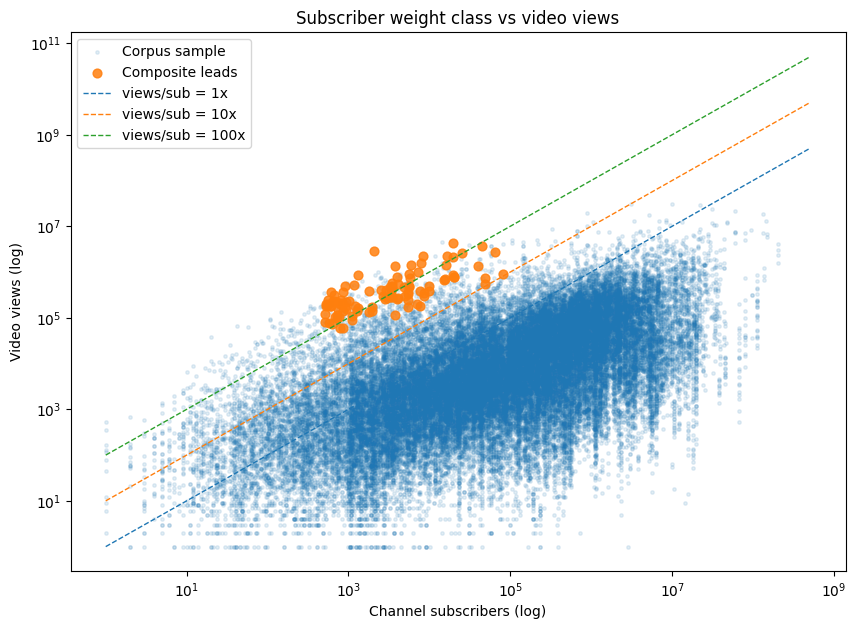

In [13]:
import matplotlib.pyplot as plt

plot_df = full_df[['video_id', 'subscribers', 'views', 'sub_class', 'views_per_sub']].copy()
plot_df['subscribers'] = pd.to_numeric(plot_df['subscribers'], errors='coerce')
plot_df['views'] = pd.to_numeric(plot_df['views'], errors='coerce')
plot_df = plot_df[(plot_df['subscribers'] > 0) & (plot_df['views'] > 0)]

# Downsample the 258k-row background so the notebook remains responsive.
background_plot = plot_df.sample(n=min(50_000, len(plot_df)), random_state=42)
lead_ids = set(composite_leads['video_id'].astype(str))
lead_plot = plot_df[plot_df['video_id'].astype(str).isin(lead_ids)]

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(background_plot['subscribers'], background_plot['views'], s=6, alpha=0.12, label='Corpus sample')
ax.scatter(lead_plot['subscribers'], lead_plot['views'], s=40, alpha=0.85, label='Composite leads')

x_min = max(plot_df['subscribers'].min(), 1)
x_max = plot_df['subscribers'].max()
x_values = np.logspace(np.log10(x_min), np.log10(x_max), 200)
for multiple in (1, 10, 100):
    ax.plot(x_values, x_values * multiple, linestyle='--', linewidth=1, label=f'views/sub = {multiple}x')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Channel subscribers (log)')
ax.set_ylabel('Video views (log)')
ax.set_title('Subscriber weight class vs video views')
ax.legend()
plt.show()

/tmp/ipykernel_2750724/148484384.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(box_data, labels=order, showfliers=False)


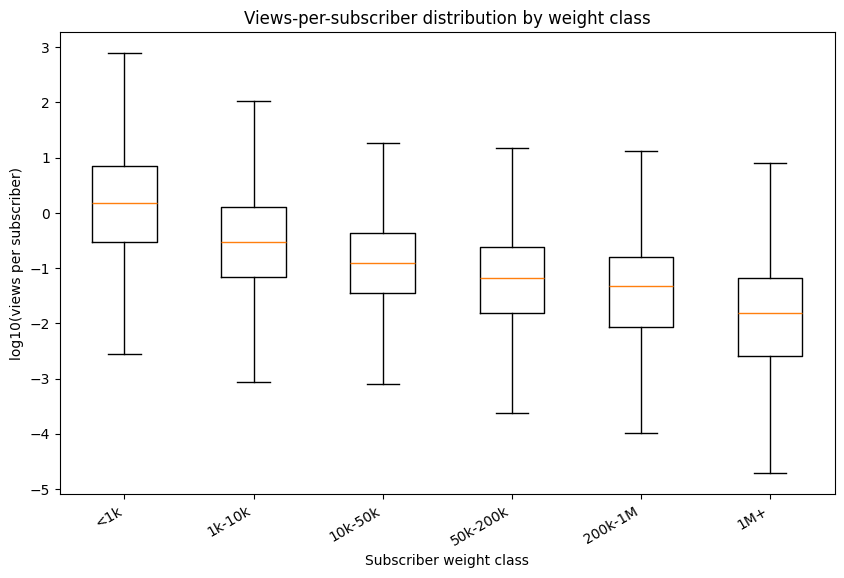

In [14]:
distribution_df = full_df[['sub_class', 'views_per_sub']].copy()
distribution_df['views_per_sub'] = pd.to_numeric(distribution_df['views_per_sub'], errors='coerce')
distribution_df = distribution_df[np.isfinite(distribution_df['views_per_sub']) & (distribution_df['views_per_sub'] > 0)]
distribution_df['log10_views_per_sub'] = np.log10(distribution_df['views_per_sub'].clip(lower=1e-6))

order = [label for label in metrics.SUB_WEIGHT_CLASSES if label in set(distribution_df['sub_class'].astype(str))]
box_data = [
    distribution_df.loc[distribution_df['sub_class'].astype(str).eq(label), 'log10_views_per_sub'].sample(
        n=min(20_000, distribution_df['sub_class'].astype(str).eq(label).sum()),
        random_state=42,
    )
    for label in order
]

fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(box_data, labels=order, showfliers=False)
ax.set_xlabel('Subscriber weight class')
ax.set_ylabel('log10(views per subscriber)')
ax.set_title('Views-per-subscriber distribution by weight class')
plt.xticks(rotation=30, ha='right')
plt.show()

## 8. Themes & Niches

`topics.extract_themes` finds recurring lead-title terms with lift versus the full background corpus. `topics.niche_saturation` summarizes categories where outliers concentrate. Read `saturation_score` as: high outlier rate plus comparatively few distinct channels means a potentially underserved niche.

Both are computed over the cross-algorithm lead union (`leads._topic_input_leads`, the same input `run_algorithms` hands to `topics.score`), not over the TOP_N composite table. A theme is by definition a term recurring across at least `min_lead_count` distinct titles from `min_distinct_channels` channels, so a 100-row input can only ever yield a few dozen of them; the union of every algorithm's outliers is the corpus those thresholds were written for.

In [15]:
# Themes are extracted from the same cross-algorithm lead union the pipeline feeds `topics.score`,
# not from the final TOP_N composite table. TOP_N distinct titles cannot support `min_lead_count=3`
# for more than a few dozen terms, so sourcing this cell from `composite_leads` pinned the output
# near 35 themes no matter how large the display slice was. The union is resolved back through
# `full_df` so the rows carry the enriched columns (`views`, `views_per_sub`, `category_id`) the
# theme aggregates are computed from.
MAX_THEMES = 200

theme_params = copy.deepcopy(PARAMS.get('topics', {}))
theme_union = ra_leads._topic_input_leads(algorithm_results, max_leads=theme_params.pop('max_input_leads', 5_000))
theme_leads = full_df[full_df['video_id'].astype(str).isin(set(theme_union['video_id'].astype(str)))]
print(f'Theme corpus: {len(theme_leads)} leads from the cross-algorithm union; composite table holds {len(composite_leads)}.')

# `extract_themes` already ranks by its composite (lift x log lead_count x log effective_channels
# x burst), so the slice is taken on that ranking and only reordered for reading. Selecting on
# `median_views_per_sub` instead would pick 200 of ~3.3k terms by a median over as few as
# `min_lead_count` videos, which surfaces long-tail noise over genuine recurring themes.
top_themes = topics.extract_themes(theme_leads, background=full_df, **theme_params).head(MAX_THEMES).sort_values(by='median_views_per_sub', ascending=False)
print(f'Themes passing min_lead_count/min_distinct_channels: {len(top_themes)} shown (cap {MAX_THEMES}).')

niche_saturation = topics.niche_saturation(full_df, theme_leads, **theme_params)
display(niche_saturation)

Theme corpus: 5000 leads from the cross-algorithm union; composite table holds 100.
Themes passing min_lead_count/min_distinct_channels: 200 shown (cap 200).


,category_id,category_name,distinct_channels,outlier_channels,total_videos,outlier_videos,outlier_rate,median_outlier_subscribers,saturation_score
0,15,Pets & Animals,154,29,2067,45,0.021771,34800.0,0.004317
1,1,Film & Animation,764,165,10683,247,0.023121,73500.0,0.003482
2,23,Comedy,375,57,4166,86,0.020643,664000.0,0.003481
3,26,Howto & Style,369,49,4018,75,0.018666,40000.0,0.003157
4,28,Science & Technology,383,49,3945,69,0.017490,271000.0,0.002939
5,25,News & Politics,815,306,35663,666,0.018675,672000.0,0.002785
6,19,Travel & Events,244,25,2451,36,0.014688,77750.0,0.002670
7,22,People & Blogs,4445,875,59662,1283,0.021504,5840.0,0.002560
8,27,Education,967,139,12593,206,0.016358,82500.0,0.002379
9,17,Sports,1305,206,25214,403,0.015983,58300.0,0.002228


In [16]:
pd.set_option('display.max_rows', 100)
top_themes.head(100)

,term,ngram_size,lead_count,lead_share,background_share,lift,burst,median_views,median_views_per_sub,distinct_channels,channel_hhi,effective_channels,example_titles,example_video_ids
66,fairy fountain,2,4,0.000827,0.000067,15.539297,1.408960,116846.0,411.152873,4,0.250000,4.000000,Great Fairy Fountain (Slowed) | Zelda Great fa...,-eXmxQ0qI2c | 0p-Iz_7HQNM | kCtuQn2m8sU
96,movie comments,2,3,0.000620,0.000055,15.095317,1.776515,268345.0,358.848387,3,0.333333,3.000000,2 Idiots Laughing At Angry Birds Movie Comment...,2dUy10vOBw0 | mu2Pob8bghM | wKew-pZ1XzU
125,markiplier,1,4,0.000827,0.000094,11.007002,1.395214,278620.5,339.584359,4,0.250000,4.000000,Markiplier reveals THE TRUTH about FNAF 2 CHEA...,4QV9m36mNhQ | vZ4lMGvq6AU | wypIjb67F2c
32,birds movie,2,12,0.002481,0.000180,14.931237,0.504443,220485.0,258.928125,12,0.083333,12.000000,Why Angry Birds Movie 3 Won't Work | 2 Idiots ...,-z9N6Vfiy94 | 2dUy10vOBw0 | 3AiBBkeqjBs
103,funny stop,2,3,0.000620,0.000027,30.190634,0.742906,199918.0,256.964010,2,0.555556,1.800000,Matt Damon Bloopers So Funny They Had to STOP ...,6TFmOttT0lU | GlREd4fBux0 | rConjotPSHw
195,ya phonk,2,3,0.000620,0.000039,21.133444,0.430104,200002.0,214.364416,3,0.333333,3.000000,YARA YARA YA PHONK ⚡Ultra Slowed | Best Phonk ...,0ZV1pci9Lzs | 0prHUP83ULY | j0-_obES0yY
37,great fairy,2,5,0.001034,0.000070,17.611203,1.318060,94970.0,191.751200,5,0.200000,5.000000,Great Fairy Fountain (Slowed) | Zelda Great fa...,-eXmxQ0qI2c | 0p-Iz_7HQNM | kCtuQn2m8sU
49,flower man,2,19,0.003929,0.000458,9.031386,0.485094,123066.0,184.070588,19,0.052632,19.000000,"Flower Man - DELTARUNE, but it's every cover p...",37BJRpCgw7M | 3_RnrWWAWKM | 4ozrbua__WQ
23,deltarune sfx,2,3,0.000620,0.000023,35.222406,2.723990,219641.0,171.594531,2,0.555556,1.800000,Random Deltarune Rotoscope gifs but with Delta...,ClhkPeu1mMQ | en65no2auG8 | w6oU4uf6_yQ
39,random deltarune,2,3,0.000620,0.000027,30.190634,2.228719,219641.0,171.594531,2,0.555556,1.800000,Random Deltarune Rotoscope gifs but with Delta...,ClhkPeu1mMQ | en65no2auG8 | w6oU4uf6_yQ


## 9. Export

In [17]:
if EXPORT:
    export_path = ra_leads.export_leads(composite_leads, EXPORT_PATH)
    composite_leads.attrs['export_path'] = str(export_path.resolve())
    print(f'Wrote composite leads CSV: {export_path.resolve()}')
else:
    composite_leads.attrs['export_path'] = None
    print('EXPORT is False; no CSV written.')

Wrote composite leads CSV: /home/orangepi/code_projects/skimmer/data/output/2026-08-06101039.csv


## 10. Checkpoint Cache

The slow load/enrich and scoring steps above are cached as Parquet in `data/cache/leads/`. Each entry is keyed by the database path, size, and modification time, by the analysis parameters, and by a hash of the `scripts/RecomendationAnalysis` sources, so new ingests, parameter changes, and algorithm edits all invalidate it automatically.

Use the cell below to inspect entries. Set `CLEAR_CACHE = True` to delete them, for example after many parameter sweeps have accumulated stale entries.


In [18]:
CLEAR_CACHE = False  # Set True to delete cached checkpoints, then re-run this cell.
CLEAR_CACHE_KIND = None  # None clears every kind; use 'analysis_frame', 'algorithm_results', or 'raw_joined'.

if CLEAR_CACHE:
    removed = checkpoint.clear_cache(CACHE_DIR, kind=CLEAR_CACHE_KIND)
    print(f'Removed {removed} cached entries from {checkpoint.resolve_cache_dir(CACHE_DIR)}.')

cache_entries = checkpoint.describe_cache(CACHE_DIR)
print(f'Cache directory: {checkpoint.resolve_cache_dir(CACHE_DIR)}')
display(cache_entries if not cache_entries.empty else pd.DataFrame([{'note': 'cache is empty'}]))


Cache directory: /home/orangepi/code_projects/skimmer/data/cache/leads


,key,created_at,frames,rows,size_mb
0,algorithm_results-0803685b5a85c5491196,2026-08-05T06:01:21.587298+00:00,6,27584,5.43
1,algorithm_results-15523cb3cc1780cda07f,2026-08-05T00:39:15.273759+00:00,6,42641,8.59
2,algorithm_results-3c381b7cf1c1a6ce8d7b,2026-08-05T03:38:12.788541+00:00,6,32503,6.39
3,algorithm_results-3e95f99d18c3dc19710c,2026-08-05T02:21:08.771140+00:00,6,32508,6.40
4,algorithm_results-52ff930f6c14fb186b7c,2026-08-05T06:12:17.652652+00:00,6,27585,5.43
5,algorithm_results-55ffb7fda55359cccb53,2026-08-05T02:45:44.209649+00:00,6,32505,6.39
6,algorithm_results-656b7a7519437d776ba4,2026-08-06T02:16:55.581170+00:00,6,28743,5.67
7,algorithm_results-86a4be4081a20d144c1e,2026-08-05T05:10:24.219701+00:00,6,29311,5.74
8,algorithm_results-8c11c93f4a8385503bd1,2026-08-06T01:43:38.300883+00:00,6,28742,5.67
9,algorithm_results-8d42fe14108556c4fd13,2026-08-05T23:40:29.489955+00:00,6,27582,5.44


## 11. Exclusions

Review throws up leads that are outliers by every metric the algorithms measure and still are not ideas worth having: devotional upload farms, a sport you do not cover, studio marketing. No statistical filter catches these, because there is nothing statistically wrong with them. The judgement is human and it is stable across runs, so it lives in `data/title_exclusions.json` rather than in a cell, and the parameters cell reloads it at the top of every run.

A rule is a **set of terms that must all appear in the same title**. One term is a plain ban (`'fifa'`); two or more express co-occurrence, which is what lets `'jesus' + 'god message'` remove the devotional farms without removing every video that mentions Jesus. Terms match on word boundaries against a lowercased, punctuation-stripped title, so `'fifa'` never fires on "Fifations" and casing is irrelevant. A term containing a space is a contiguous phrase (`'official trailer'`); to mean "both of these words anywhere in the title", pass them as separate terms instead.

A term ending in `*` matches any word **starting** with that stem, so `'america*'` covers "America", "American" and "Americans" in one term. The reaction-channel template is the case that needs it: its variation is derivational rather than plural ("Europe" / "European" / "Europeans"), so `'american' + 'british'` silently missed "...Things Only **Americans** Do", and writing one rule per spelling meant three rules that each missed the next spelling. Stemming is opt-in per term because making it the default would broaden every existing rule — `'god*'` reaches "Godzilla", "goddess" and "godfather" — and would leave no way to express an exact term. A loose stem is kept honest by co-occurrence: `'brit*'` alone would take Britney Spears with it, but `'brit*' + 'america*'` is the template nearly every time. A stem still has to start a word, so `'america*'` never fires inside "PanAmerican", and it must be at least 3 characters.

`scope` decides *when* a rule is applied, and the difference is not cosmetic.

`'leads'` (the default) removes matches from the scored results after the algorithms have run. The videos still count towards weight-class norms, background term frequencies and niche saturation. This is right for taste: a football video remains valid evidence about the market even when you never want one suggested. It costs no recompute, because it is applied to the cached scores, so adding a rule means re-running section 5 downwards rather than the whole notebook.

`'corpus'` removes matches before `metrics.enrich`, so they never reach the norms, theme lift or saturation baselines at all. This is right for content that is distorting the measurements themselves, which is the same argument this notebook already makes for Shorts and for non-English channels. It changes the analysis frame, so it invalidates that checkpoint and the next run rebuilds it.

Start at `'leads'`. Promote a rule to `'corpus'` only once you can see it skewing the theme table, because that is the scope you cannot undo without paying for a rebuild.

`APPLY_EXCLUSION_EDITS` is `False` by default so that running the notebook top to bottom never mutates the rule file as a side effect.

In [19]:
APPLY_EXCLUSION_EDITS = False  # Set True to write the edits below to disk, then re-run from section 2.

# Each entry is a dict: 'terms' (a string, or a list whose terms are ANDed together), plus optional
# 'scope' ('leads' or 'corpus'), 'fields' (defaults to ['title']) and 'note'.
# A term ending in '*' is a stem: 'america*' matches America, American and Americans alike. Prefer one
# stemmed rule over several spellings of the same rule, and check its reach in the table below before
# trusting it, because a stem is by design broader than what you typed.
ADD_EXCLUSIONS = [
    # {'terms': ['jesus', 'god message'], 'note': 'devotional upload farms'},
    # {'terms': 'fifa', 'note': 'not a niche I cover'},
    # {'terms': 'official trailer', 'note': 'studio marketing, not a creator idea'},
    # Already saved: these two stemmed rules replaced ['american','british'] and the three
    # ['europeans','americans'] / ['european','american'] / ['european','america'] spellings.
    # {'terms': ['america*', 'brit*'], 'note': 'reaction-channel template'},
    # {'terms': ['america*', 'europe*'], 'note': 'reaction-channel template'},
    # {'terms': 'god message', 'scope': 'corpus', 'note': 'promote once it starts skewing theme lift'},
]

# Removal must name the same scope as the rule being removed, since the same terms can be saved
# under both scopes.
REMOVE_EXCLUSIONS = [
    # {'terms': 'fifa'},
]

exclusion_path = exclusions.default_path() if EXCLUSIONS_PATH is None else Path(EXCLUSIONS_PATH)
saved_rules = exclusions.load(EXCLUSIONS_PATH)
pending_rules = list(saved_rules)

for entry in ADD_EXCLUSIONS:
    pending_rules, was_added = exclusions.add(
        entry['terms'],
        scope=entry.get('scope', exclusions.DEFAULT_SCOPE),
        fields=entry.get('fields'),
        note=entry.get('note'),
        rules=pending_rules,
    )
    if not was_added:
        print(f"Already present, skipped: {entry['terms']!r}")

for entry in REMOVE_EXCLUSIONS:
    pending_rules, was_removed = exclusions.remove(
        entry['terms'],
        scope=entry.get('scope', exclusions.DEFAULT_SCOPE),
        fields=entry.get('fields'),
        rules=pending_rules,
    )
    if not was_removed:
        print(f"No saved rule matched, nothing removed: {entry['terms']!r} (check its scope)")

print(f'Exclusion file: {exclusion_path}')
print(f'{len(saved_rules)} saved rule(s); {len(pending_rules)} after the edits in this cell.')

# Two views before trusting a rule. Reach is measured against raw_df, the frame before every filter,
# because full_df has already had the corpus-scoped rules applied and would report them as zero.
# A rule matching nothing is usually a typo or an over-specific phrase; one matching a large share of
# the corpus is usually a term too generic to mean what you intended.
if pending_rules:
    reach = exclusions.summarize(raw_df, pending_rules).rename(
        columns={'matched_rows': 'raw_videos', 'matched_share': 'raw_share'}
    )
    display(reach)

    # And what it costs right now: how many of the current composite leads each rule would take out.
    cost = exclusions.summarize(composite_leads, pending_rules, examples=1)[['rule', 'matched_rows', 'examples']]
    display(cost.rename(columns={'matched_rows': 'composite_leads_removed'}))
else:
    print('No rules defined yet. Uncomment an entry in ADD_EXCLUSIONS above to start.')

if APPLY_EXCLUSION_EDITS:
    written = exclusions.save(pending_rules, EXCLUSIONS_PATH)
    print(f'Wrote {len(pending_rules)} rule(s) to {written}.')
    print('Re-run from section 2 to apply them: lead-scoped rules take effect at section 5,')
    print('corpus-scoped rules rebuild the analysis frame first.')
else:
    print('APPLY_EXCLUSION_EDITS is False; nothing was written. The tables above are a preview only.')

Exclusion file: /home/orangepi/code_projects/skimmer/data/title_exclusions.json
6 saved rule(s); 6 after the edits in this cell.


,rule,scope,terms,raw_videos,raw_share,examples
0,'fifa' [leads on title],leads,fifa,2922,0.005402,olombia 1-0 Ghana Highlights | Arias Winner Se...
1,'america*' AND 'europe*' [leads on title],leads,america* AND europe*,1061,0.001962,Europeans Tourists Were SHOCKED By American Fo...
2,'official trailer' [leads on title],leads,official trailer,943,0.001743,AVENGERS DOOMSDAY OFFICIAL TRAILER REACTION | ...
3,'america*' AND 'brit*' [leads on title],leads,america* AND brit*,535,0.000989,I Would Never Move to America — Says Brits Who...
4,'god says' [leads on title],leads,god says,174,0.000322,Stop Doubting—God Says You're Blessed | Bishop...
5,'god message' [leads on title],leads,god message,155,0.000287,"🔴God Is Speaking Through This Video, Stay Unti..."


,rule,composite_leads_removed,examples
0,'fifa' [leads on title],0,
1,'official trailer' [leads on title],0,
2,'america*' AND 'brit*' [leads on title],0,
3,'america*' AND 'europe*' [leads on title],0,
4,'god message' [leads on title],0,
5,'god says' [leads on title],0,


APPLY_EXCLUSION_EDITS is False; nothing was written. The tables above are a preview only.
